<a href="https://colab.research.google.com/github/melissa-04/spatial-transcriptomics-learning-project/blob/main/notebooks/00_setup_and_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install squidpy -q
import squidpy as sq
import scanpy as sc
import anndata as ad
print("squidpy :", sq.__version__)
print("scanpy: ", sc.__version__)
print("anndata: ", ad.__version__)

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.1/54.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.3/272.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.6/51.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.

/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'n_jobs' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/usr/local/lib/python3.12/dist-packages/docrep/decorators.py:43: SyntaxWarning: 'show_progress_bar' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


squidpy : 1.8.2
scanpy:  1.12.1
anndata:  0.12.18


/tmp/ipykernel_32588/2471476492.py:6: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy: ", sc.__version__)
/tmp/ipykernel_32588/2471476492.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata: ", ad.__version__)


In [2]:
adata = sq.datasets.merfish()
print("===adata summmary ===")
print(adata)
print("\n===shape===")
print(f"{adata.n_obs} cells * {adata.n_vars} genes")
print("\n=== adata.obs (first 5 cells) ===")
print(adata.obs.head())
print("\n=== adata.obsm['spatial'] (first 5 cells) ===")
print(adata.obsm["spatial"][:5])

INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/merfish.h5ad                        


  0%|                                              | 0.00/51.6M [00:00<?, ?B/s]

===adata summmary ===
AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

===shape===
73655 cells * 161 genes

=== adata.obs (first 5 cells) ===
                                      Cell_ID  Animal_ID Animal_sex Behavior  \
67146-0  6d6b1d59-6f3b-4a9d-b5a4-8c8b073ae025          1     Female    Naive   
67147-0  76200644-c14a-4cfa-8752-2a02e5f10d20          1     Female    Naive   
67148-0  6b08ca36-b395-415a-bb34-d7b67550c35d          1     Female    Naive   
67149-0  b9cb9cfb-fff7-426e-8c36-18fe428ca156          1     Female    Naive   
67150-0  982cc0fc-6d11-4dc4-9ffc-c8c0cee48e6d          1     Female    Naive   

         Bregma  Centroid_X   Centroid_Y     Cell_class Neuron_cluster_ID  \
67146-0   -29.0  467.385973 -3983.113569    OD Mature 2               nan   
67147-0   -29.0  509

In [5]:
import numpy as np
from scipy.sparse import issparse
print("type of X: ", type(adata.X))
print("is sparse: ", issparse(adata.X))
print("dtype  : ", adata.X.dtype)
print("min: ",float(adata.X.min()))
print("max: ",float(adata.X.max()))
print("mean : %.4f" % float (adata.X.mean()))
print("\n=== first 10 gene names===")
print(list(adata.var_names[:10]))
corner = adata.X[:5, :5]
corner = corner.toarray() if issparse(corner) else np.asarray(corner)
print("\n=== X[:5, :5]===")
print(np.round(corner,3))

type of X:  <class 'scipy.sparse._csr.csr_matrix'>
is sparse:  True
dtype  :  float32
min:  0.0
max:  369.5953674316406
mean : 1.5539

=== first 10 gene names===
['Ace2', 'Adora2a', 'Aldh1l1', 'Amigo2', 'Ano3', 'Aqp4', 'Ar', 'Arhgap36', 'Avpr1a', 'Avpr2']

=== X[:5, :5]===
[[ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.63  40.295  0.   ]
 [ 0.     0.     0.     3.998  0.   ]
 [ 0.     0.     0.     0.     0.   ]]


Bregma
-29.0    6509
-24.0    6412
-19.0    6507
-14.0    6605
-9.0     6185
-4.0     6154
 1.0     6111
 6.0     6144
 11.0    5799
 16.0    6067
 21.0    5578
 26.0    5584
Name: count, dtype: int64

Chosen section: Bregma = -14.000000000000002
Cells in this section: 6605


/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:979: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


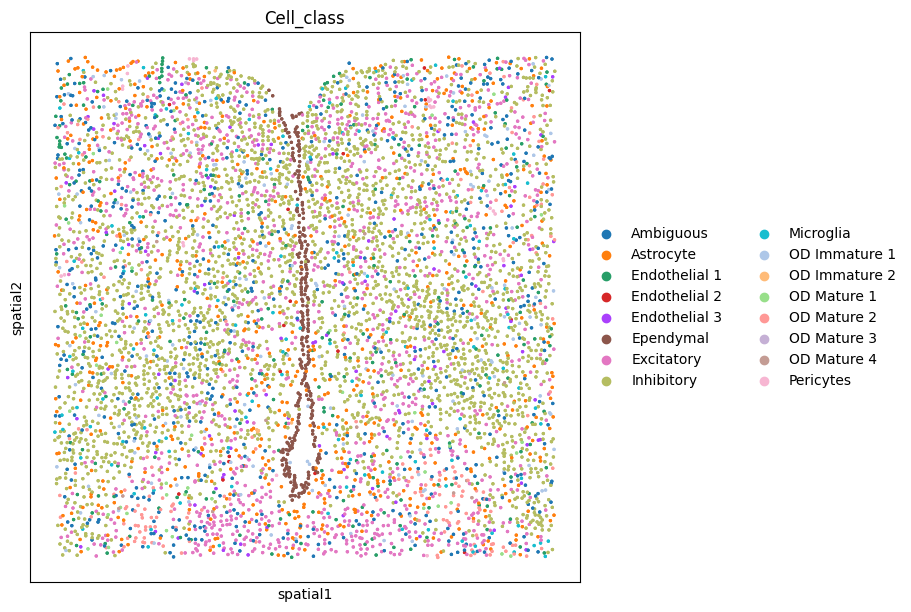

In [9]:
print(adata.obs["Bregma"].value_counts().sort_index())
bregma_value=adata.obs["Bregma"].value_counts().idxmax()
print(f"\nChosen section: Bregma = {bregma_value}")
adata_slice =adata[adata.obs["Bregma"] == bregma_value].copy()
print(f"Cells in this section: {adata_slice.n_obs}")
sq.pl.spatial_scatter(
    adata_slice,
    color ="Cell_class",
    shape=None,
    size=8,
    figsize=(9,9),
)
